# Probing the Interior Ocean

*Developed starting from activities by Sarah Purkey at Scripps Institution of Oceanography, University of
California San Diego; used in courses such as SIO 210.*

This notebook uses the Argo array to explore the mixed layer and subsurface property features of individual floats. It is organized in two parts:
- **Part 1** — Temporal mixed-layer variability: track how the MLD evolves over a year.
- **Part 2** — Subsurface ocean features: identify thermocline, halocline, water-mass extrema, and T–S structure.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

## Learning Goals

By the end of this activity, you will be able to:

1. **Identify mixed-layer variability** — recognize how the MLD shoals and deepens over time and relate it to season or spatial position.
2. **Describe subsurface features** — identify and label the mixed layer, thermocline, halocline, thermo-/halostads, and temperature/salinity extrema in ocean profiles.
3. **Read T–S diagrams** — associate clusters in T–S space with specific water masses and depth ranges.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ──────────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import gsw
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `traverse_interpolate` — interpolate all queried profiles onto a common pressure grid
- `plot_maps` — scatter profile locations on a map
- `compare_profiles` — plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`
- `plot_profiles_TSdiagram` — T/S diagram with optional coloring by a third variable
- `plot_profiles_with_mld` — plot profiles with student and algorithmic MLD markers
- `compute_derived_properties` — compute SA, CT, potential density, MLD (3 methods), and N² for each profile
- `_arr` — safely convert Profile.getvar() output to a plain float ndarray

In [2]:
# ── Helper functions — run, do not modify ────────────────────────────────────
from notebook_helpers.functions import traverse_query, traverse_interpolate, plot_maps, compare_profiles, plot_profiles_TSdiagram
from notebook_helpers.functions_MLD import plot_profiles_with_mld, compute_derived_properties
from notebook_helpers.functions_candidates_for_functions import _arr

---
## Probing the Interior Ocean

## Part 1: Temporal Variability in the Mixed Layer Depth

The **mixed layer** is the surface layer of the ocean where temperature is approximately constant with depth due to wind-driven mixing and surface heat exchange. The **mixed layer depth (MLD)** marks the base of this well-mixed layer and varies seasonally and spatially.

### Step 0 — Choose a float and note its cycle range

Visit [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo). On the platform page of a float, zoom in on the upper 500 m of the temperature and salinity time series. Look for a float that:

- Shows a **clear seasonal cycle** in the mixed layer — mid-latitude or subtropical floats in either hemisphere work well.
- Has a **relatively stable trajectory** — check the map on the platform page to confirm the float does not drift far from its starting position over the year. A drifting float mixes spatial and temporal signals, making it harder to interpret.

Argo floats typically profile every **10 days**, so one full year produces approximately **36 profiles**. Note the float's **platform (WMO) ID** (e.g. `6999985`) and the cycle numbers of the first and last profiles you want to include (visible in the ID `platform_cycle` shown in each profile pop-up).

### Setup: configuration — Part 1

✏️ **Student Work — Float Selection**

Fill in the three values below. The notebook automatically generates one profile ID per cycle, so you do not need to type them one by one. Set `CYCLE_END - CYCLE_START ≈ 36` to cover roughly one full year.

In [3]:
# MODIFY HERE
FLOAT_PLATFORM = '6999985'   # ← WMO platform number only (digits, no underscore)
CYCLE_START    = 10          # ← first cycle number to include
CYCLE_END      = 46          # ← last cycle to include  (aim for CYCLE_END - CYCLE_START ≈ 36)

# Generates all profile IDs automatically — cycles that don't exist are silently skipped
platform_profiles_p1 = [
    {"id": f"{FLOAT_PLATFORM}_{cycle:03d}"}
    for cycle in range(CYCLE_START, CYCLE_END + 1)
]
print(f"Querying {len(platform_profiles_p1)} profiles: "
      f"{FLOAT_PLATFORM}_{CYCLE_START:03d} through {FLOAT_PLATFORM}_{CYCLE_END:03d}")

# ── Fixed settings — do not modify ───────────────────────────────────────────
argo_collections_p1  = {'argo': 'temperature,1,salinity,1'}
time_range_p1        = [{"startDate": "2000-01-01T00:00:00Z", "endDate": "2030-01-01T00:00:00Z"}]
TEMP_VAR             = 'temperature'
SALT_VAR             = 'salinity'
INTERPOLATION_LEVELS = list(range(0, 2001, 5))   # 0–2000 dbar every 5 dbar
DEPTH_YLIM           = 400   # dbar — upper ocean zoom for profile plots

temperature_key = {'argo': 'temperature'}
salinity_key    = {'argo': 'salinity'}

Querying 37 profiles: 6999985_010 through 6999985_046


### Step 1 — Query and interpolate profiles

`traverse_query` fetches each profile ID from the Argovis API. Cycle numbers that do not exist for the float (e.g. skipped cycles) return empty and are automatically discarded in the flatten step.

`traverse_interpolate` resamples every retrieved profile onto a common pressure grid — **0 to 2000 dbar, every 5 dbar** — which is required for the time-sorted profile plot in Step 4. Profiles with fewer than two valid levels are silently skipped.

In [4]:
# ── Step 1: Query and interpolate — run, do not modify ───────────────────────
p1_results = traverse_query(platform_profiles_p1, time_range_p1, argo_collections_p1,
                            avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
p1_interp  = traverse_interpolate(p1_results, INTERPOLATION_LEVELS)

# Flatten nested structure into a time-sorted list
profiles_p1 = []
for ds, regions_list in p1_interp.items():
    for region_list in regions_list:
        for time_list in region_list:
            profiles_p1.extend(time_list)

profiles_p1 = [p for p in profiles_p1 if p.timestamp is not None]
profiles_p1.sort(key=lambda p: p.timestamp)
print(f"Loaded {len(profiles_p1)} profiles")

Loaded 37 profiles


### Step 2 — Compute derived properties

For each profile we compute absolute salinity, conservative temperature, potential density, and a threshold-based MLD estimate ($\Delta\sigma_\theta = 0.03$ kg/m³ from a 10 dbar reference).

In [5]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for p in profiles_p1:
    if p.hasvar(SALT_VAR) and p.hasvar(TEMP_VAR):
        compute_derived_properties(p, temperature_key, salinity_key, 'argo')

print(f"✓ Derived properties computed for {len(profiles_p1)} profiles")

✓ Derived properties computed for 37 profiles


### Step 3 — Map of float trajectory

The map below shows the positions of the queried float profiles, **colored by date** (earliest = dark, most recent = bright). Floats drift with ocean currents, so some variability you observe in the profiles may reflect spatial changes rather than purely temporal ones — use this map to judge how much the float moved.

/usr/local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


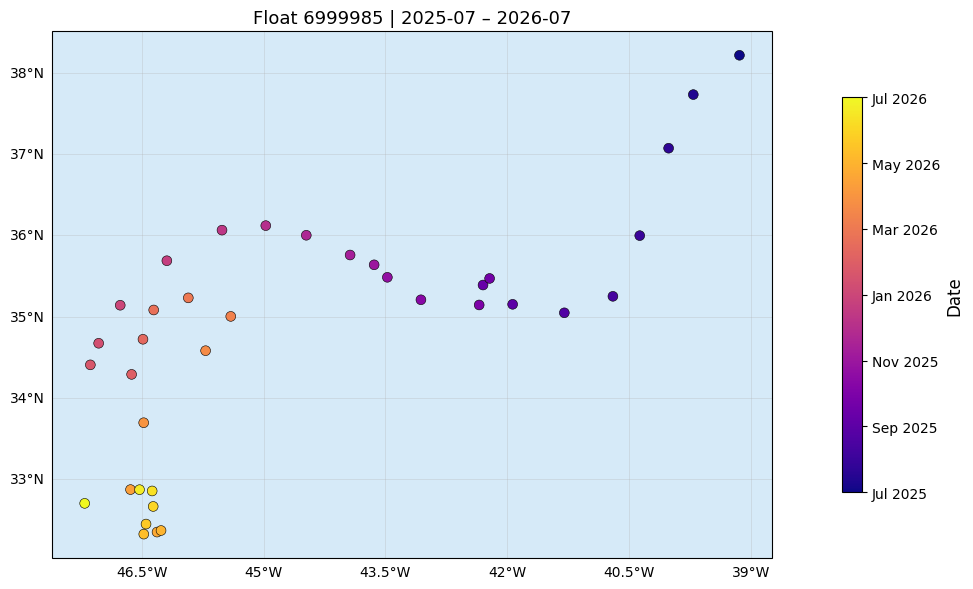

In [6]:
# ── Float trajectory map colored by date — run, do not modify ────────────────
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

lats      = [p.latitude  for p in profiles_p1]
lons      = [p.longitude for p in profiles_p1]
times_num = [mdates.date2num(p.timestamp) for p in profiles_p1]

float_id   = profiles_p1[0].rawdata['_id'].rsplit('_', 1)[0]
date_start = profiles_p1[0].timestamp.strftime('%Y-%m')
date_end   = profiles_p1[-1].timestamp.strftime('%Y-%m')

central_lon = float(np.mean(lons))

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=central_lon))
ax.set_facecolor('#d6eaf8')                                       # ocean colour — no download
ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6,          zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4)
gl.top_labels = False; gl.right_labels = False

norm_t = mcolors.Normalize(vmin=min(times_num), vmax=max(times_num))
cmap_t = plt.colormaps['plasma']
sc = ax.scatter(lons, lats, c=times_num, cmap=cmap_t, norm=norm_t,
                s=50, transform=ccrs.PlateCarree(), zorder=5,
                edgecolors='black', linewidths=0.4)

tick_times = np.linspace(min(times_num), max(times_num), 7)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.06, shrink=0.75)
cbar.set_ticks(tick_times)
cbar.set_ticklabels([mdates.num2date(t).strftime('%b %Y') for t in tick_times],
                    fontsize=10)
cbar.set_label('Date', fontsize=12)

ax.set_title(f'Float {float_id} | {date_start} – {date_end}', fontsize=13)
plt.tight_layout()
plt.show()

### Step 4 — Temperature, salinity, and potential density profiles colored by month

Each line is one profile; color indicates the **month of the year** (see colorbar). The filled square (■) marks the algorithmic MLD estimate.

We show all three variables together because they tell a complementary story:

| Variable | What it reveals |
|---|---|
| **Temperature** | Thermal stratification; the thermocline below the mixed layer |
| **Salinity** | Haline stratification; the halocline; freshwater input at the surface |
| **Potential density σθ** | The variable used to *define* the MLD: the ■ is placed where σθ first exceeds the surface (10 dbar) reference value by $\Delta\sigma_\theta = 0.03$ kg/m³ |

A well-mixed layer has **approximately constant T and S** from the surface down to the MLD. Below it, both can change rapidly (thermocline / halocline). By plotting all three you can ask: does the density criterion agree with the depth where T and S start to change, and which of the two variables drives the density stratification?

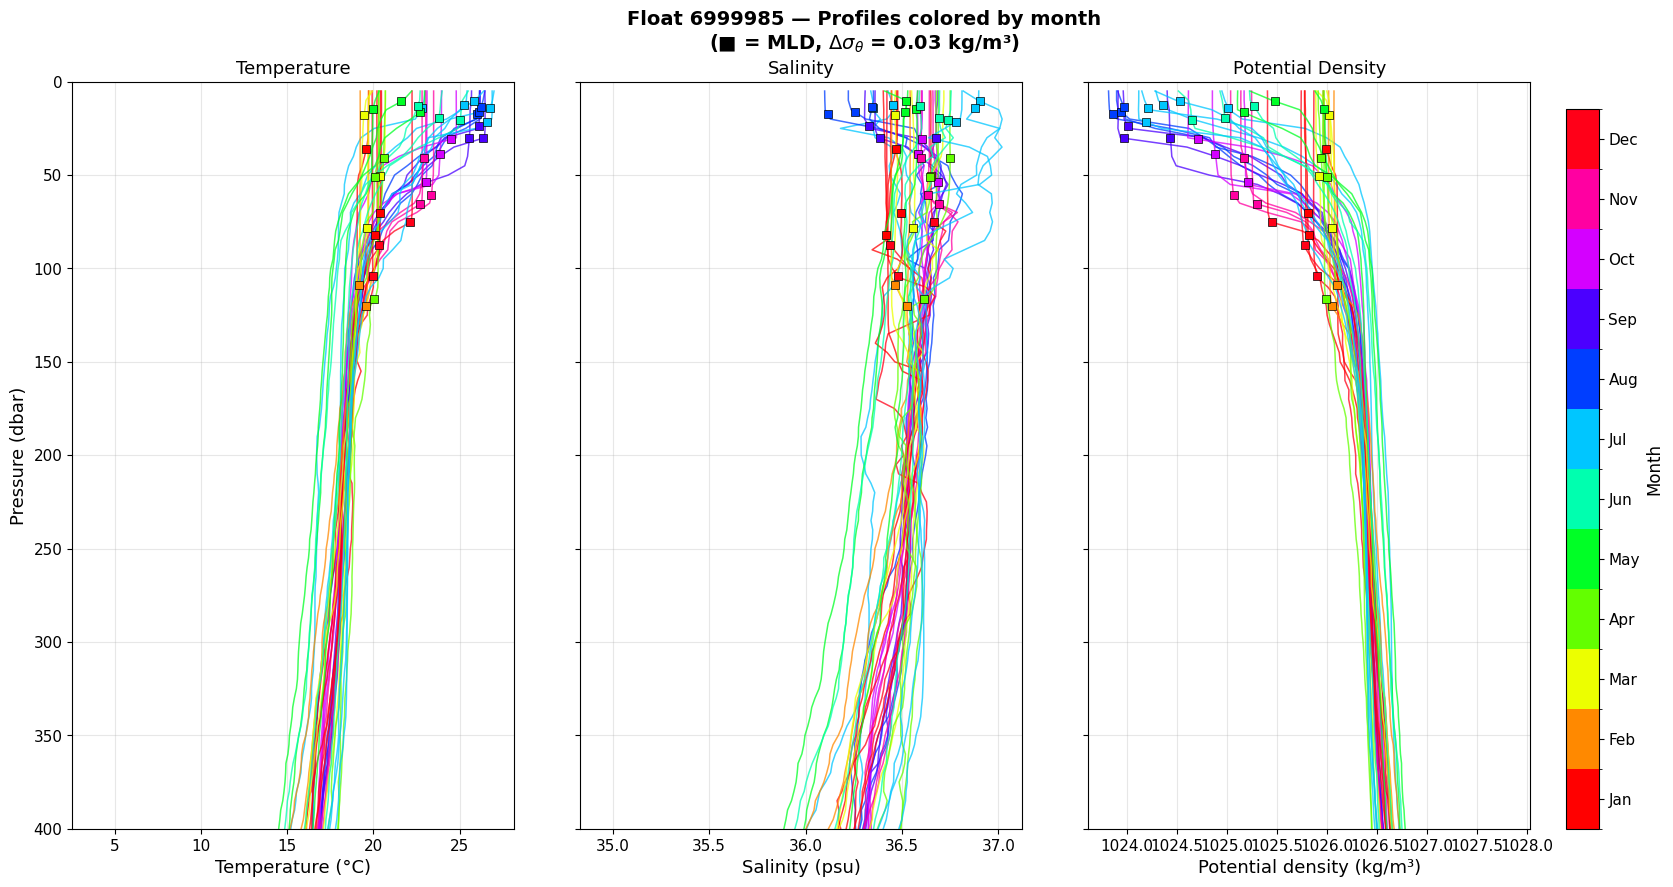

In [7]:
# ── Step 4: T, S, σθ profiles colored by month — run, do not modify ──────────
import matplotlib.colors as mcolors

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
cmap_m = plt.colormaps['hsv'].resampled(12)
norm_m = mcolors.BoundaryNorm(np.arange(0.5, 13.5), ncolors=12)

float_id = profiles_p1[0].rawdata['_id'].rsplit('_', 1)[0]

fig, (ax_t, ax_s, ax_pd) = plt.subplots(1, 3, figsize=(18, 9), sharey=True)

for p in profiles_p1:
    month = p.timestamp.month
    color = cmap_m((month - 1) / 12)
    pres = _arr(p.getvar('pressure'))
    temp = _arr(p.getvar('temperature'))
    salt = _arr(p.getvar('salinity'))
    dens = _arr(p.getvar('potential_density'))

    mld = p.getvar('MLD_potdensity')
    mld_d = float(mld[0]) if (mld is not None and mld[0] is not None) else None

    kw = dict(color=color, linewidth=1.1, alpha=0.75)

    for ax, yvar, valid_mask in [
        (ax_t,  temp, ~np.isnan(temp) & ~np.isnan(pres)),
        (ax_s,  salt, ~np.isnan(salt) & ~np.isnan(pres)),
        (ax_pd, dens, ~np.isnan(dens) & ~np.isnan(pres)),
    ]:
        if not valid_mask.any():
            continue
        ax.plot(yvar[valid_mask], pres[valid_mask], **kw)
        if mld_d is not None:
            pv = pres[valid_mask][np.argsort(pres[valid_mask])]
            vv = yvar[valid_mask][np.argsort(pres[valid_mask])]
            v_at_mld = np.interp(mld_d, pv, vv)
            ax.plot(v_at_mld, mld_d, 's', color=color, markersize=6,
                    markeredgecolor='black', markeredgewidth=0.5, zorder=10)

for ax in [ax_t, ax_s, ax_pd]:
    ax.set_ylim(DEPTH_YLIM, 0)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=11)

ax_t.set_xlabel('Temperature (°C)',          fontsize=13)
ax_s.set_xlabel('Salinity (psu)',             fontsize=13)
ax_pd.set_xlabel('Potential density (kg/m³)', fontsize=13)
ax_t.set_ylabel('Pressure (dbar)',            fontsize=13)
ax_t.set_title('Temperature',                 fontsize=13)
ax_s.set_title('Salinity',                    fontsize=13)
ax_pd.set_title('Potential Density',          fontsize=13)

fig.suptitle(f'Float {float_id} — Profiles colored by month\n'
             r'($\blacksquare$ = MLD, $\Delta\sigma_\theta$ = 0.03 kg/m³)',
             fontsize=14, fontweight='bold')

# Colorbar positioned manually so it doesn't overlap the σθ panel
sm = plt.cm.ScalarMappable(cmap=cmap_m, norm=norm_m)
sm.set_array([])
fig.subplots_adjust(left=0.06, right=0.87, top=0.90, bottom=0.07, wspace=0.15)
cax = fig.add_axes([0.89, 0.07, 0.018, 0.80])
cbar = fig.colorbar(sm, cax=cax, ticks=range(1, 13))
cbar.set_ticklabels(MONTH_NAMES, fontsize=11)
cbar.set_label('Month', fontsize=12)
plt.show()

### Step 5 — Mixed-layer depth and properties over time

The four panels below show, as time series: the MLD, and the mean temperature, salinity, and potential density **within** the mixed layer (i.e., averaged from the surface down to the MLD). A deeper MLD means stronger mixing; a shallower MLD means the surface layer has stratified. The property time series reveal how seasonal mixing and surface fluxes drive the mixed-layer state.

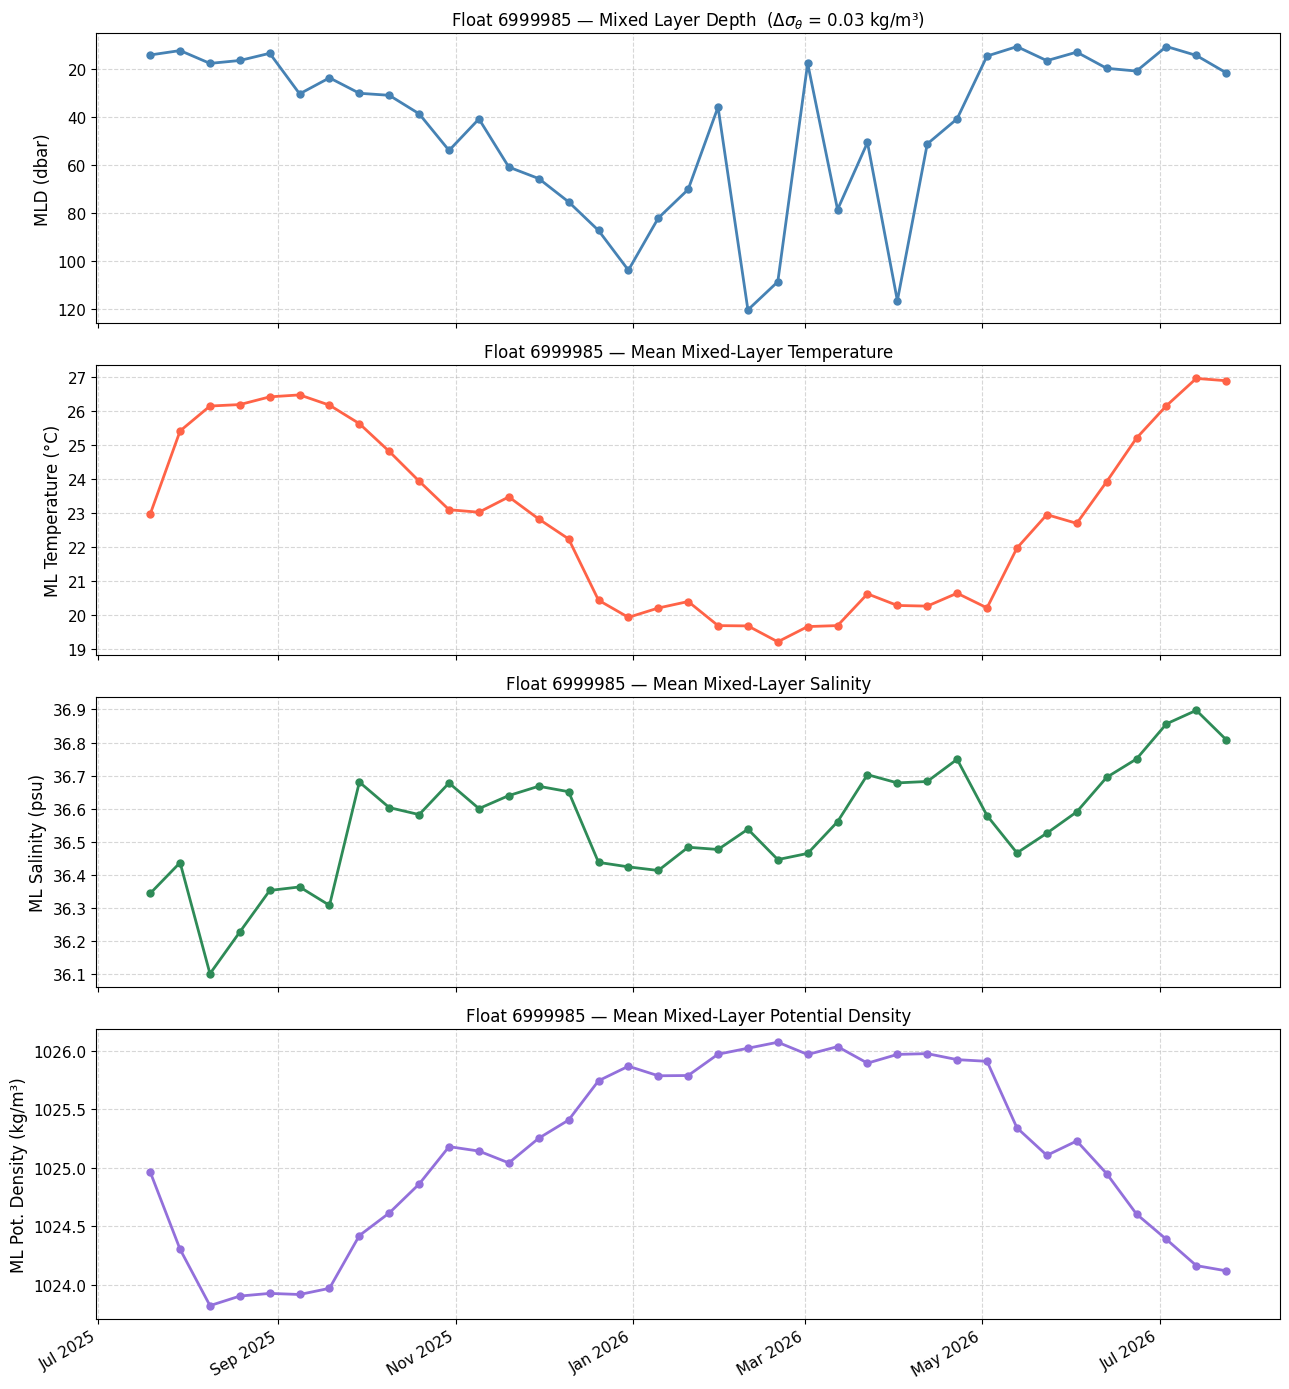

In [8]:
# ── Step 5: MLD and mixed-layer properties over time — run, do not modify ─────
float_id = profiles_p1[0].rawdata['_id'].rsplit('_', 1)[0]

mld_times, mld_depths = [], []
ml_temp, ml_salt, ml_dens = [], [], []

for p in profiles_p1:
    mld = p.getvar('MLD_potdensity')
    if mld is None or mld[0] is None or p.timestamp is None:
        continue
    mld_d = float(mld[0])
    pres  = _arr(p.getvar('pressure'))
    temp  = _arr(p.getvar('temperature'))
    salt  = _arr(p.getvar('salinity'))
    dens  = _arr(p.getvar('potential_density'))

    in_ml = pres <= mld_d
    if in_ml.sum() < 2:
        continue

    mld_times.append(p.timestamp)
    mld_depths.append(mld_d)
    ml_temp.append(float(np.nanmean(temp[in_ml])))
    ml_salt.append(float(np.nanmean(salt[in_ml])))
    ml_dens.append(float(np.nanmean(dens[in_ml])))

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

series = [
    (mld_depths, 'MLD (dbar)',             'steelblue',  True),
    (ml_temp,    'ML Temperature (°C)',     'tomato',     False),
    (ml_salt,    'ML Salinity (psu)',        'seagreen',   False),
    (ml_dens,    'ML Pot. Density (kg/m³)', 'mediumpurple', False),
]

titles = [
    r'Mixed Layer Depth  ($\Delta\sigma_\theta$ = 0.03 kg/m³)',
    'Mean Mixed-Layer Temperature',
    'Mean Mixed-Layer Salinity',
    'Mean Mixed-Layer Potential Density',
]

for ax, (vals, ylabel, color, invert), title in zip(axes, series, titles):
    ax.plot(mld_times, vals, 'o-', color=color, markersize=5, linewidth=2.0)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Float {float_id} — {title}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)
    if invert:
        ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## ✏️ Student Work — Question 1: Mixed Layer Temporal Variability

Using the plots above, answer the following questions.

1. Describe the temporal variability you observe in the mixed layer. Does the MLD shoal and deepen, and if so, at what time of year is it shallowest? Is this what you would expect for the hemisphere your float is in?
2. Compare the individual profiles in Step 4. Does the float's trajectory (Step 3) suggest that spatial drift might be contributing to the variability you observe in the profiles, or does the variability look primarily temporal (seasonal)?
3. Looking at the salinity and potential density panels in Step 4: are temperature and salinity both well mixed within the mixed layer (approximately constant from the surface down to the MLD marker)? Does one variable show more structure than the other just below the MLD? What does that suggest about what drives the stratification?
4. Looking at the time series in Step 5: describe the seasonal cycle of mixed-layer temperature, salinity, and potential density. Which property shows the largest seasonal amplitude relative to its mean? Is the timing of the ML property extrema consistent with the seasonal MLD cycle (i.e., does the deepest MLD coincide with the densest, coldest mixed layer)?

*Double-click to edit this cell and write your answer.*

---
## Part 2: Subsurface Ocean Features

Ocean profiles contain rich structure below the mixed layer. In this part you will select three to four profiles from different locations or seasons, plot them, and label key vertical features:

- The **base of the mixed layer** and its temperature and salinity
- The **thermocline** and **halocline** — depths and property ranges
- Any **thermo-** or **halostads** — depth intervals of nearly constant temperature or salinity
- All local **temperature and salinity maxima and minima** (signatures of water masses)

### Step 0 — Choose your profiles

Go to [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo). Click on individual profiles (not just floats) and note the full profile ID shown in the pop-up — it has the form `platform_cycle`, e.g. `7902209_042`. Pick three to four profiles that look interesting to you. You may reuse profiles from Part 1 or choose new ones.

### Setup: configuration — Part 2

✏️ **Student Work — Profile Selection**

Replace the example IDs below with your chosen profile IDs. Add or remove entries as needed (3–4 profiles recommended).

In [9]:
# MODIFY HERE
feature_profiles = [
    {"id": "7902209_042"},
    {"id": "5905656_273"},
    {"id": "5905572_070"},
]

# Enter your profile IDs here:
# feature_profiles = [
#     {"id": "ID1"},
#     {"id": "ID2"},
#     {"id": "ID3"},
# ]

FEATURE_COLORS     = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
FEATURE_TIME       = [{"startDate": "2000-01-01T00:00:00Z", "endDate": "2030-01-01T00:00:00Z"}]
FEATURE_DEPTH_YLIM = 1000   # dbar

### Step 1 — Query and interpolate profiles

In [10]:
# ── Step 1: Query profiles — run, do not modify ───────────────────────────────
feat_results  = traverse_query(feature_profiles, FEATURE_TIME,
                               {'argo': 'temperature,1,salinity,1'},
                               avh.queryProfile, apikey=APIKEY, apiroot=APIROOT)
feat_profiles = traverse_interpolate(feat_results, INTERPOLATION_LEVELS)

n_found = sum(len(tl) for rl in feat_profiles.get('argo', []) for tl in rl)
print(f"Loaded {n_found} profile(s)")

Loaded 3 profile(s)


### Step 2 — Compute derived properties

In [11]:
# ── Compute derived properties — run, do not modify ──────────────────────────
for ds, regions_list in feat_profiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            for p in time_list:
                if p.hasvar('temperature') and p.hasvar('salinity'):
                    compute_derived_properties(p, temperature_key, salinity_key, ds)

print("✓ Computed: SA, CT, potential density, MLD estimates, N²")

✓ Computed: SA, CT, potential density, MLD estimates, N²


### Step 3 — Temperature, salinity, and potential density profiles

The three panels below show each profile side by side. Use them to identify the features listed in the activity instructions.

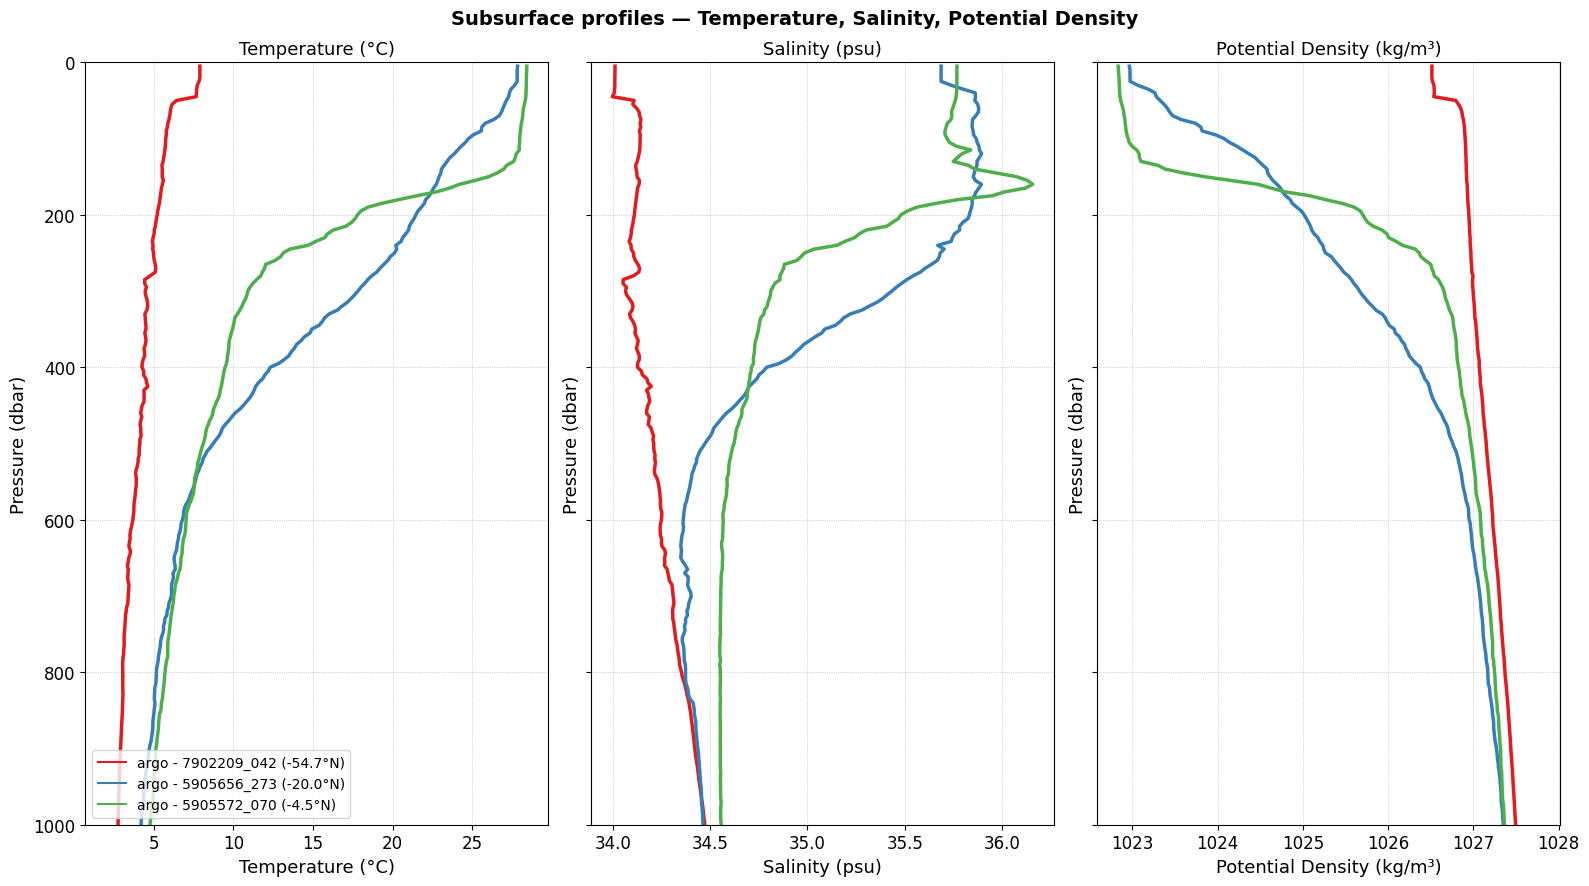

In [12]:
# ── Three-panel profile plot — run, do not modify ─────────────────────────────
fig, (ax_t, ax_s, ax_pd) = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

all_handles = []
color_idx = 0
for ds, regions_list in feat_profiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            if not time_list:
                continue
            p = time_list[0]
            color  = FEATURE_COLORS[color_idx % len(FEATURE_COLORS)]
            label  = f"{p.rawdata['_id']} ({p.latitude:.1f}°N)"
            dc     = {ds: color}

            for ax, var in [(ax_t, 'temperature'), (ax_s, 'salinity'), (ax_pd, 'potential_density')]:
                h = compare_profiles(
                    {ds: [p]}, varname=var,
                    dataset_colors=dc, time_linestyles=['-'],
                    depth_ylim=FEATURE_DEPTH_YLIM, mean_style=True,
                    ax=ax, datestring=label,
                )
                if ax is ax_t:
                    all_handles.extend(h)
            color_idx += 1

# Thicken lines, fix font sizes, and override the raw x-axis labels set by compare_profiles
for ax in [ax_t, ax_s, ax_pd]:
    for line in ax.get_lines():
        line.set_linewidth(2.5)
    ax.tick_params(labelsize=12)
    ax.yaxis.label.set_size(13)

ax_t.set_xlabel('Temperature (°C)',           fontsize=13)
ax_s.set_xlabel('Salinity (psu)',              fontsize=13)
ax_pd.set_xlabel('Potential Density (kg/m³)',  fontsize=13)
ax_t.set_title('Temperature (°C)',             fontsize=13)
ax_s.set_title('Salinity (psu)',               fontsize=13)
ax_pd.set_title('Potential Density (kg/m³)',   fontsize=13)
ax_t.legend(handles=all_handles, fontsize=10, loc='lower left')
plt.suptitle('Subsurface profiles — Temperature, Salinity, Potential Density',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4 — T–S diagram

The T–S diagram plots each data point as temperature vs. salinity, with color indicating pressure (depth). Water masses occupy characteristic regions in T–S space.

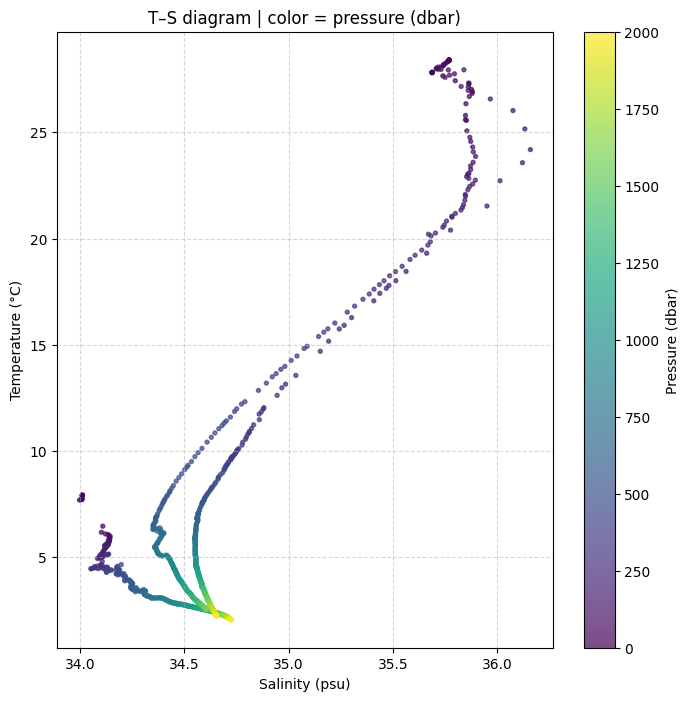

In [13]:
# ── T–S diagram colored by pressure — run, do not modify ─────────────────────
valuesT, valuesS, valuesPres = [], [], []
for ds, regions_list in feat_profiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            for p in time_list:
                t = p.getvar('temperature')
                s = p.getvar('salinity')
                pr = p.getvar('pressure')
                if t is not None and s is not None and pr is not None:
                    valuesT.append(_arr(t))
                    valuesS.append(_arr(s))
                    valuesPres.append(_arr(pr))

plot_profiles_TSdiagram(
    valuesT, valuesS, 'Temperature (°C)', 'Salinity (psu)',
    values_to_color=valuesPres,
    title='T–S diagram | color = pressure (dbar)',
    fig_settings={'cbar_label': 'Pressure (dbar)', 'alpha': 0.7, 'markersize': 8},
)

## ✏️ Student Work — Question 2: Annotating Mixed Layer, Thermocline, and Halocline Features

For each of your 3–4 profiles, annotate the three-panel figure by identifying and labeling the features listed in the following:

- **Base of the mixed layer** — note its depth (dbar) and the temperature and salinity at that depth.
- **Thermocline and halocline** — note the depth range and the span in temperature or salinity across each.
- **Thermo- and halostads** — depth intervals of nearly constant temperature or salinity below the mixed layer (if present).
- **Temperature and salinity maxima and minima** — note the depth and value of each local extremum.

Do all profiles have a well-defined thermocline and halocline? Are their depths and strengths similar across your profiles, or do they differ? What physical factors might explain the differences?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 3: Temperature and Salinity Extrema

Are there local temperature or salinity maxima or minima present in any profile? If so, at what depth, and can you associate them with water masses discussed in lecture?

*Double-click to edit this cell and write your answer.*

## ✏️ Student Work — Question 4: T–S Diagram Overlap and Water Mass Distribution

In the T–S diagram, do the profiles overlap in T–S space? What does overlap (or separation) tell you about the water masses present at different locations?

*Double-click to edit this cell and write your answer.*